In [ ]:
# Imports & Configuração inicial
import time
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.ndimage import label
from scipy.optimize import linear_sum_assignment
from torchvision import models
from torchvision.models import ResNet18_Weights

# Configuração de dispositivo (MPS em Mac, CUDA em NVIDIA, senão CPU)
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")

elif torch.cuda.is_available():print(f"Usando dispositivo: {device}")

    device = torch.device("cuda")

else:    device = torch.device("cpu")

Usando dispositivo: cpu


In [25]:
# --- Arquitetura U-Net com Backbone ResNet18 ---

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels // 2 + skip_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x, skip):
        x = self.up(x)
        x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


class UNetResNet(nn.Module):
    def __init__(self, out_channels=1, pretrained=True, freeze_backbone=True):
        super().__init__()
        backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT if pretrained else None)

        if freeze_backbone:
            for param in backbone.parameters():
                param.requires_grad = False

        self.backbone = backbone
        self.encoder0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.encoder1 = backbone.layer1
        self.encoder2 = backbone.layer2
        self.encoder3 = backbone.layer3
        self.encoder4 = backbone.layer4

        self.center = nn.Sequential(
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

        self.up4 = DecoderBlock(512, 256, 256)
        self.up3 = DecoderBlock(256, 128, 128)
        self.up2 = DecoderBlock(128, 64, 64)
        self.up1 = DecoderBlock(64, 64, 64)
        self.head = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        input_hw = x.shape[-2:]
        x0 = self.encoder0(x)      # 64 channels, H/4
        x1 = self.encoder1(x0)     # 64 channels, H/4
        x2 = self.encoder2(x1)     # 128 channels, H/8
        x3 = self.encoder3(x2)     # 256 channels, H/16
        x4 = self.encoder4(x3)     # 512 channels, H/32

        x = self.center(x4)
        x = self.up4(x, x3)
        x = self.up3(x, x2)
        x = self.up2(x, x1)
        x = self.up1(x, x0)
        logits = self.head(x)
        return F.interpolate(logits, size=input_hw, mode="bilinear", align_corners=False)


# Teste de integridade da arquitetura
model_test = UNetResNet(out_channels=1).to(device)
dummy_in = torch.randn(2, 3, 128, 128, device=device)
dummy_out = model_test(dummy_in)
print(f"Modelo U-Net carregado. Formato de saída para batch (2, 3, 128, 128): {tuple(dummy_out.shape)}")

Modelo U-Net carregado. Formato de saída para batch (2, 3, 128, 128): (2, 1, 128, 128)


In [39]:
# Gerador de elipses

def generate_ellipse(image, center, axes, angle, color=None, thickness=-1):
    if color is None:
        color = (
            int(np.random.randint(0, 256)),
            int(np.random.randint(0, 256)),
            int(np.random.randint(0, 256)),
        )
    return cv2.ellipse(image, center, axes, angle, 0, 360, color, thickness)


def gerar_dataset_elipses(num_images=100, image_size=(128, 128), num_ellipses_range=(5, 20)):
    images = []
    masks = []

    for _ in range(num_images):
        img = np.zeros((image_size[0], image_size[1], 3), dtype=np.uint8)
        mask = np.zeros(image_size, dtype=np.uint8)
        num_ellipses = np.random.randint(num_ellipses_range[0], num_ellipses_range[1] + 1)

        for _ in range(num_ellipses):
            center = (np.random.randint(0, image_size[1]), np.random.randint(0, image_size[0]))
            axes = (np.random.randint(5, 20), np.random.randint(5, 20))
            angle = np.random.randint(0, 360)
            color = (
                int(np.random.randint(0, 256)),
                int(np.random.randint(0, 256)),
                int(np.random.randint(0, 256)),
            )

            img = generate_ellipse(img, center, axes, angle, color=color, thickness=-1)
            mask = generate_ellipse(mask, center, axes, angle, color=255, thickness=-1)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

dataset = gerar_dataset_elipses(num_images=10)

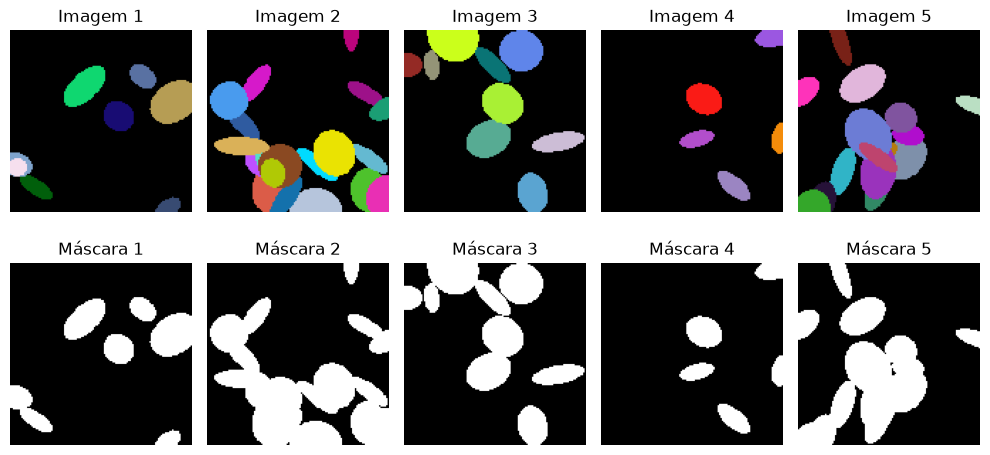

In [40]:
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(dataset[0][i])
    plt.title(f'Imagem {i+1}')
    plt.axis('off')

    plt.subplot(2, 5, i + 6)
    plt.imshow(dataset[1][i], cmap='gray')
    plt.title(f'Máscara {i+1}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [45]:
# Split do dataset em treino e validação
X_train, y_train = dataset[0][:8], dataset[1][:8]
X_test, y_test = dataset[0][8:], dataset[1][8:]

# Treinar modelo
def train_model(model, dataset, num_epochs=10, batch_size=4, learning_rate=0.001):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss()

    images, masks = dataset
    num_samples = images.shape[0]
    num_batches = num_samples // batch_size

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0

        for i in range(num_batches):
            batch_images = images[i * batch_size:(i + 1) * batch_size]
            batch_masks = masks[i * batch_size:(i + 1) * batch_size]

            # Convert to torch tensors and move to device
            batch_images_tensor = torch.tensor(batch_images, dtype=torch.float32).permute(0, 3, 1, 2).to(device) / 255.0
            batch_masks_tensor = torch.tensor(batch_masks, dtype=torch.float32).unsqueeze(1).to(device) / 255.0

            optimizer.zero_grad()
            outputs = model(batch_images_tensor)
            loss = criterion(outputs, batch_masks_tensor)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / num_batches
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}')

# Inicializar e treinar o modelo
model = UNetResNet(out_channels=1, pretrained=True, freeze_backbone=True)
train_model(model, dataset, num_epochs=10, batch_size=4, learning_rate=0.001)


Epoch [1/10], Loss: 0.5996
Epoch [2/10], Loss: 0.3702
Epoch [3/10], Loss: 0.2944
Epoch [4/10], Loss: 0.2690
Epoch [5/10], Loss: 0.2551
Epoch [6/10], Loss: 0.2442
Epoch [7/10], Loss: 0.2344
Epoch [8/10], Loss: 0.2257
Epoch [9/10], Loss: 0.2178
Epoch [10/10], Loss: 0.2102


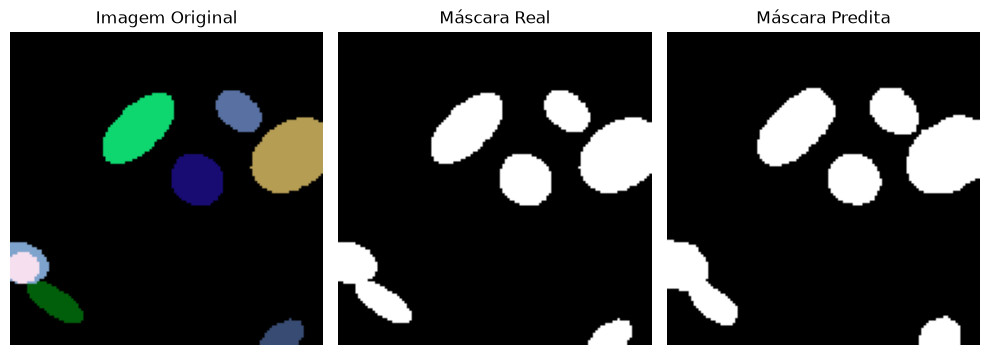

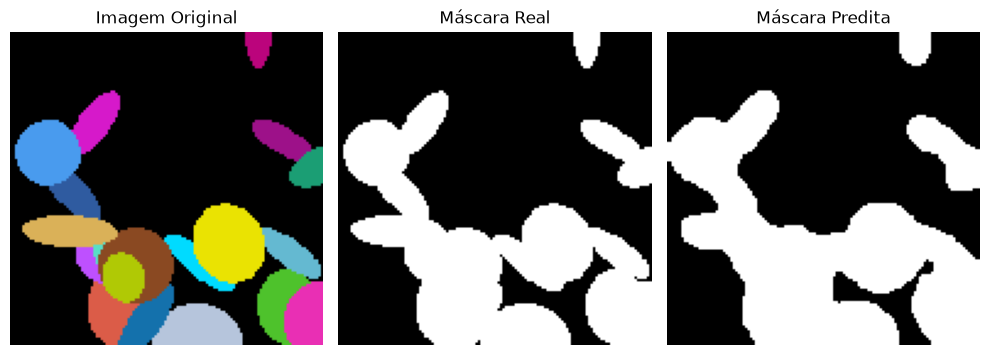

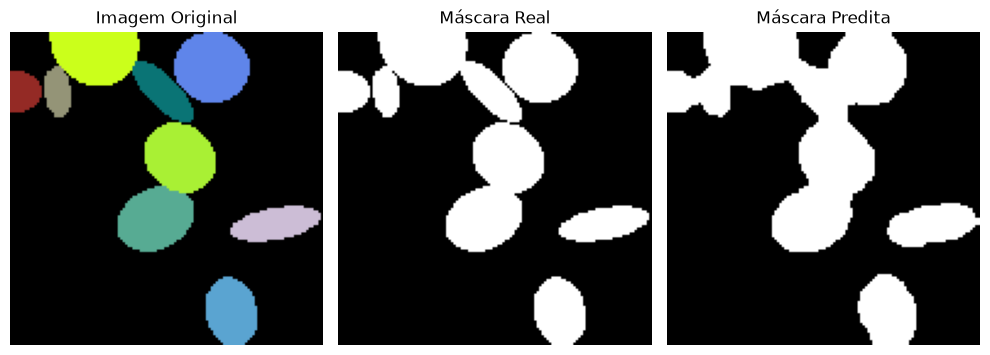

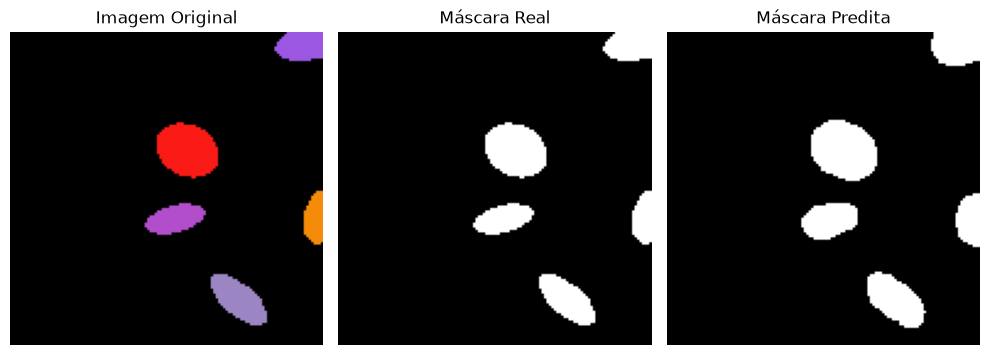

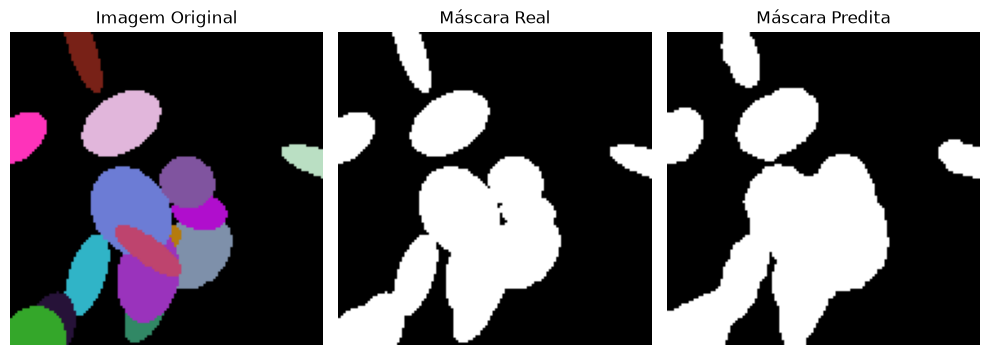

In [46]:
# Teste do modelo treinado
def test_model(model, dataset, num_samples=5):
    model.eval()
    images, masks = dataset

    with torch.no_grad():
        for i in range(num_samples):
            img = images[i]
            mask = masks[i]

            # Convert to torch tensor and move to device
            img_tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device) / 255.0

            output = model(img_tensor)
            output_mask = torch.sigmoid(output).squeeze().cpu().numpy()
            output_mask_binary = (output_mask > 0.5).astype(np.uint8) * 255

            plt.figure(figsize=(10, 5))
            plt.subplot(1, 3, 1)
            plt.imshow(img)
            plt.title('Imagem Original')
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(mask, cmap='gray')
            plt.title('Máscara Real')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(output_mask_binary, cmap='gray')
            plt.title('Máscara Predita')
            plt.axis('off')

            plt.tight_layout()
            plt.show()

# Testar o modelo treinado
test_model(model, dataset, num_samples=5)

In [ ]:
# Calcular métricas de avaliação (Dice, IoU)
def calculate_dice_coefficient(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-6)

def calculate_iou(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return intersection / (union + 1e-6)